# Weighted Pair Correlation Functions (weighted-netPCF)

In the previous tutorials, we used the network pair correlation function (`netPCF`) and cross-network pair correlation function (`cross-netPCF`) to quantify the spatial organisation of discrete node populations over a spatial network. In both cases, every node contributed equally to the estimated pair correlation function.

In many applications, however, nodes are associated with continuous measurements rather than simple categorical labels. Examples from spatial biology include molecular expression levels, fluorescence intensities, cell areas, or any other quantitative property. In these settings, it is often desirable to quantify how these continuous values are spatially organised, rather than simply the locations of the nodes themselves.

The weighted network pair correlation function (weighted-netPCF) extends the pair correlation framework by allowing each node to contribute to the estimated correlation according to an associated weight. Instead of estimating the density of neighbouring nodes, the statistic estimates the weighted density of neighbouring nodes as a function of network distance. As before, the observed weighted densities are compared with those expected under a statistical null model, producing a scale-dependent measure of spatial association.

This methodology was introduced in:

**Moore et al. (2026). *netPCF: Geometry-aware Pair Correlation Functions for Spatial Biology*.** DOI: ...

In this tutorial, we'll demonstrate the practical application of the weighted network pair correlation function using `weighted_pair_correlation_function()`. We'll use the example spiral dataset and assign continuous weights to each node to illustrate how the statistic can identify spatial patterns in quantitative node attributes.

(<Figure size 1500x600 with 4 Axes>, <Axes: >)

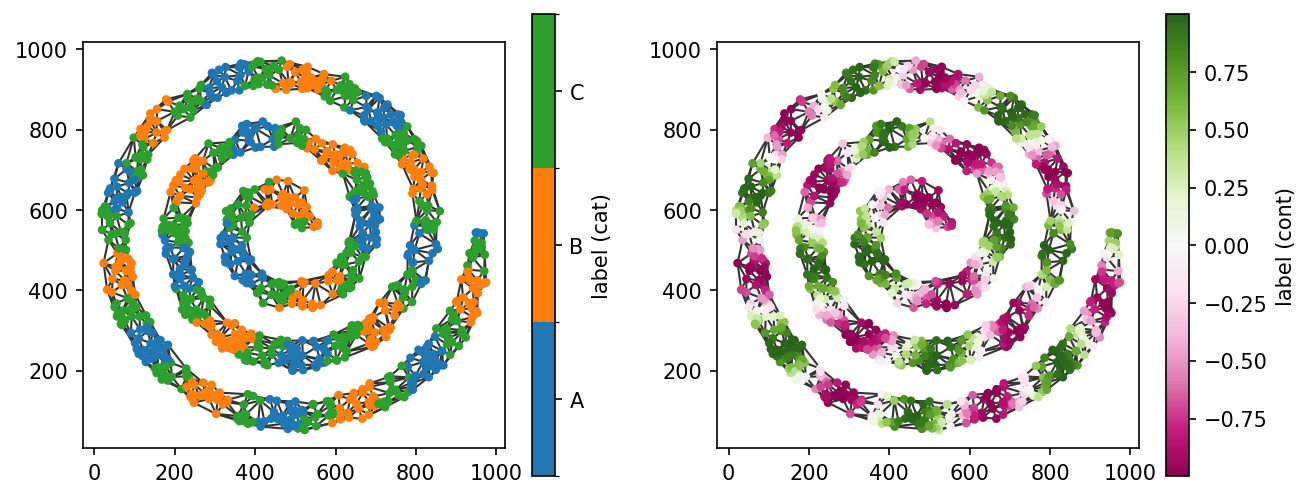

In [1]:
import spacenet as sn
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 150

# load in the example dataset 'sprial'
spiral_data = sn.datasets.load_dataset('spiral')

# extract the point data and labels
points = np.array([spiral_data['x'],spiral_data['y']]).T
cat_labels = spiral_data['Marker (categorical)']
cont_labels = spiral_data['Marker (continuous)']

# generate a spatial network and add the labels
spatial_net = sn.utils.spatial_network_from_points(points,max_edge_distance=75)
sn.utils.add_node_labels(spatial_net,labels=cat_labels,node_label_name='label (cat)')
sn.utils.add_node_labels(spatial_net,labels=cont_labels,node_label_name='label (cont)')

# plot the spatial network with nodes colored by the demo labels 
fig,ax=plt.subplots(1,2,figsize=(10,4))
sn.utils.plot_spatial_network(spatial_net,node_label_name='label (cat)',ax=ax[0])
sn.utils.plot_spatial_network(spatial_net,node_label_name='label (cont)',ax=ax[1],scatter_kwargs={'cmap':'PiYG'})

The example spatial network now contains both categorical and continuous node labels. In this tutorial, we'll compute the weighted network pair correlation function using all nodes labelled `A` as the reference population, while weighting the target population according to the values of the continuous node label.

The first step is to identify the nodes labelled `A`, which we can do using SpaceNet's querying functionality.


In [2]:
# get the node IDs of all nodes with label A and B
nodes_A = sn.utils.query_nodes(spatial_net,node_label_name='label (cat)',relation='==',node_label_value='A')

We can now compute the weighted network pair correlation function using `weighted_pair_correlation_function()`. In addition to the parameters introduced in the previous tutorials, this function requires information describing the continuous node attribute and the range of values over which the weighted correlation should be evaluated.

The key additional parameters are:

* `node_label_name_b`: the name of the continuous node label to use as the weighting variable.
* `marker_kernel_bandwidth`: the one-sided bandwidth of the kernel used to estimate local densities in marker (weight) space.
* `marker_min`: the minimum marker value to evaluate.
* `marker_max`: the maximum marker value to evaluate.
* `marker_step`: the spacing between successive marker values.

All remaining parameters are the same as those used for `netPCF` and `cross-netPCF`. The marker range should be chosen to span the values present in the dataset. In this example, the continuous node labels lie between **−1** and **1**, so we'll use these as the lower and upper bounds.

Let's now compute the weighted network pair correlation function.

In [3]:
# estimate the pair correlation between nodes with label A and all nodes with the continuous label, label (cont)
target_marks,radii,wpcf_values,conf_inter=sn.point_patterns.weighted_pair_correlation_function(spatial_net,
                                                                                               node_label_name_b='label (cont)',
                                                                                               nodes_a=nodes_A,
                                                                                               marker_kernel_bandwidth = 0.2,
                                                                                               marker_min = -1,
                                                                                               marker_max = 1,
                                                                                               marker_step = 0.05,
                                                                                               spatial_kernel_bandwidth=50,
                                                                                               r_max=500,
                                                                                               r_step=10,
                                                                                               return_confidence_interval=True)

Computing node-node distances...


Computing contributions: 100%|██████████| 326/326 [00:02<00:00, 137.71contributions/s]


Computing confidence intervals via spatial bootstrap...


In addition to the outputs returned by `netPCF` and `cross-netPCF`, `weighted_pair_correlation_function()` returns `target_marks`, which contains the marker values at which the weighted pair correlation function has been evaluated.

Consequently, the estimated pair correlation values are now two-dimensional. Rather than varying only with network distance, the weighted pair correlation function is evaluated over both network distance (`radii`) and marker value (`target_marks`). We can see this by inspecting the shapes of the returned arrays.


In [9]:
print('The shape of the w-netPCF output:',wpcf_values.shape)
print('The shape of target marks array:',target_marks.shape)
print('The shape of radii array:',radii.shape)

The shape of the w-netPCF output: (41, 51)
The shape of target marks array: (41,)
The shape of radii array: (51,)


Each row of `wpcf_values` corresponds to a marker value in `target_marks`, while each column corresponds to a network distance in `radii`. In other words, the weighted pair correlation function is evaluated over the two-dimensional space defined by marker value and network distance.

To visualise this two-dimensional estimate, we'll display `wpcf_values` as a heatmap.

Text(0, 0.5, 'Target Mark, $\\tau$')

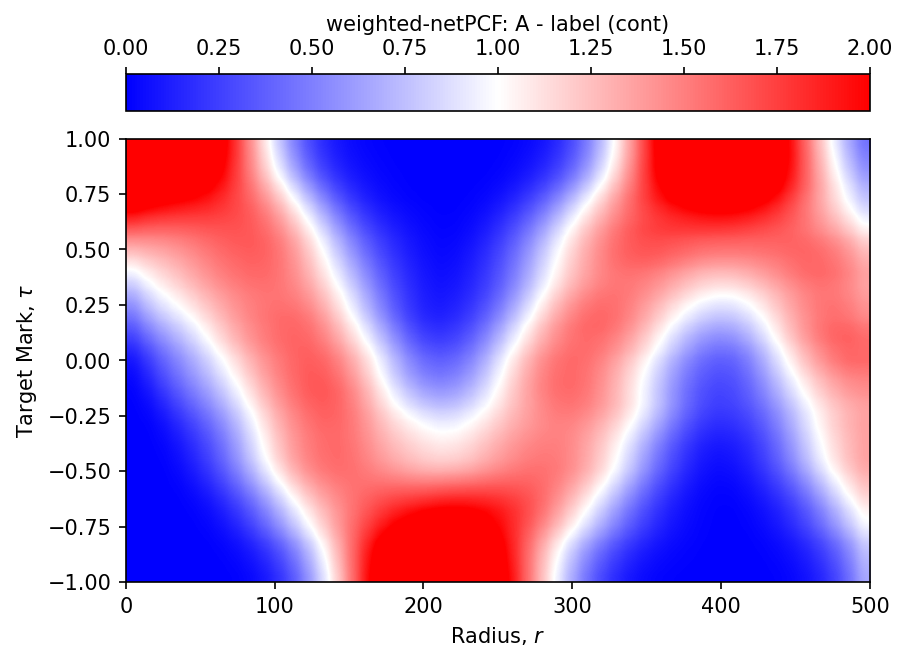

In [10]:
# plot the wpcf_values array for all target marks
fig,ax=plt.subplots()
heatmap=ax.imshow(wpcf_values,origin='lower',interpolation='gaussian',cmap='bwr',vmin=0,vmax=2,aspect='auto',extent=[np.min(radii), np.max(radii),np.min(target_marks), np.max(target_marks)])

cbar=fig.colorbar(heatmap,ax=ax, location='top')
cbar.set_label('weighted-netPCF: A - label (cont)')

ax.set_xlabel('Radius, $r$')
ax.set_ylabel('Target Mark, $\\tau$')

As with the previous pair correlation functions, the weighted network pair correlation function is interpreted relative to the complete spatial randomness (CSR) expectation. Values greater than **1** indicate positive spatial association, while values less than **1** indicate spatial exclusion.

In this example, the heatmap shows that, at network distances below approximately **100** distance units, nodes labelled `A` are preferentially associated with nodes having larger marker values (approximately greater than **0.5**). At around **200** distance units, this relationship reverses, with nodes labelled `A` becoming preferentially associated with smaller marker values. This behaviour reflects the underlying spatial organisation of the example dataset.

The key advantage of the weighted network pair correlation function is that it estimates spatial associations across the entire range of marker values simultaneously, providing a compact summary of how spatial organisation varies with both network distance and the continuous node attribute.

To make this interpretation more intuitive, we can extract and plot pair correlation curves at selected marker values. These one-dimensional slices are analogous to the `netPCF` and `cross-netPCF` curves presented in the previous tutorials.

Text(0, 0.5, 'w-netPCF ($\\tau=-0.75$)')

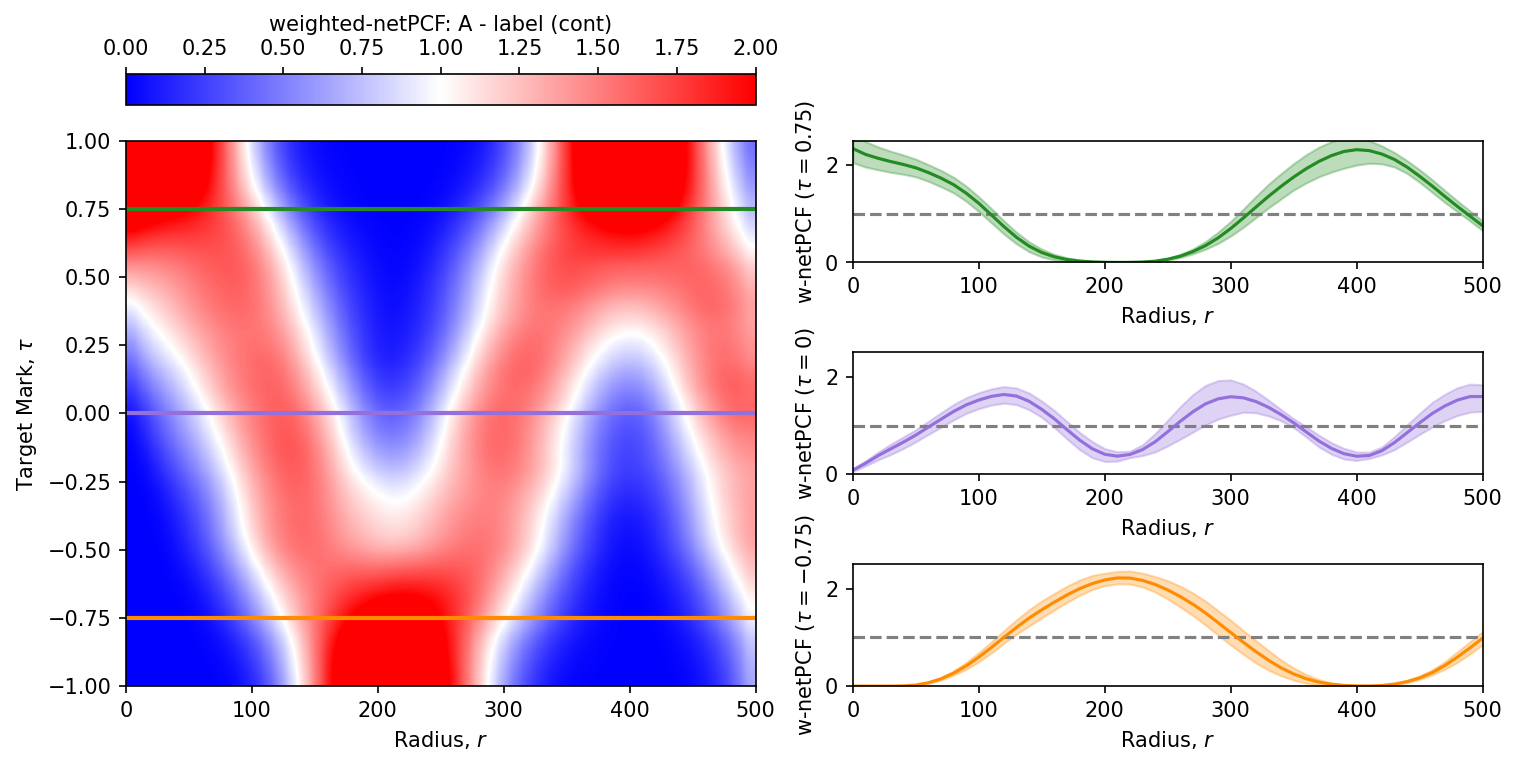

In [8]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(layout="constrained",figsize=(10,5))
gs = GridSpec(3, 2, figure=fig)

ax1 = fig.add_subplot(gs[:,0])
ax2 = fig.add_subplot(gs[0,1])
ax3 = fig.add_subplot(gs[1,1])
ax4 = fig.add_subplot(gs[2,1])

# plot the heatmap 
heatmap=ax1.imshow(wpcf_values,origin='lower',interpolation='gaussian',cmap='bwr',vmin=0,vmax=2,aspect='auto',extent=[np.min(radii), np.max(radii),np.min(target_marks), np.max(target_marks)])

cbar=fig.colorbar(heatmap,ax=ax1, location='top')
cbar.set_label('weighted-netPCF: A - label (cont)')

ax1.set_xlabel('Radius, $r$')
ax1.set_ylabel('Target Mark, $\\tau$')

ax1.axhline(0.75,color='forestgreen',linewidth=2)
ax1.axhline(0,color='mediumpurple',linewidth=2)
ax1.axhline(-0.75,color='darkorange',linewidth=2)


# get the indices of the target marks of interest
index_at_pos_75 = np.where(np.isclose(target_marks,0.75))[0][0]
index_at_0 = np.where(np.isclose(target_marks,0))[0][0]
index_at_neg75 = np.where(np.isclose(target_marks,-0.75))[0][0]

# plot netPCF curves for target = 0.75
ax2.axhline(1,linestyle='--',color='grey')
ax2.fill_between(radii,conf_inter[0,index_at_pos_75,:],conf_inter[1,index_at_pos_75,:],color='forestgreen',alpha=0.3)
ax2.plot(radii,wpcf_values[index_at_pos_75,:],color='forestgreen')
ax2.set_xlim([0,500])
ax2.set_ylim([0,2.5])
ax2.set_xlabel('Radius, $r$')
ax2.set_ylabel('w-netPCF ($\\tau=0.75$)')

# plot netPCF curves for target = 0
ax3.axhline(1,linestyle='--',color='grey')
ax3.fill_between(radii,conf_inter[0,index_at_0,:],conf_inter[1,index_at_0,:],color='mediumpurple',alpha=0.3)
ax3.plot(radii,wpcf_values[index_at_0,:],color='mediumpurple')
ax3.set_xlim([0,500])
ax3.set_ylim([0,2.5])
ax3.set_xlabel('Radius, $r$')
ax3.set_ylabel('w-netPCF ($\\tau=0$)')

# plot netPCF curves for target = -0.75
ax4.axhline(1,linestyle='--',color='grey')
ax4.fill_between(radii,conf_inter[0,index_at_neg75,:],conf_inter[1,index_at_neg75,:],color='darkorange',alpha=0.3)
ax4.plot(radii,wpcf_values[index_at_neg75,:],color='darkorange')
ax4.set_xlim([0,500])
ax4.set_ylim([0,2.5])
ax4.set_xlabel('Radius, $r$')
ax4.set_ylabel('w-netPCF ($\\tau=-0.75$)')

In this tutorial, we've introduced the weighted network pair correlation function (`weighted-netPCF`) and demonstrated how it can be used to quantify the spatial organisation of continuous node attributes over a spatial network. Unlike `netPCF` and `cross-netPCF`, the weighted formulation simultaneously characterises spatial associations across the full range of marker values, providing a compact representation of how spatial organisation varies with both network distance and continuous node properties.

For a complete description of the available parameters, outputs, and additional functionality, see the documentation for `weighted_pair_correlation_function()`.